<a href="https://colab.research.google.com/github/PrerikaP1331/ml---lab---5th-sem/blob/main/ML_LAB_Experiment_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ***Using Decision Trees The Iris Flower Dataset***

Installing essential Python Libraries

- pandas: For loading and manipulating data.
- scikit-learn: The go-to library for machine learning in Python.
- matplotlib & seaborn: For data visualization.

In [ ]:
!pip install pandas scikit-learn matplotlib seaborn

The Iris dataset is available as an inbuilt dataset in scikit-learn. We now load it into a pandas DataFrame.

In [ ]:
import pandas as pd
from sklearn.datasets import load_iris

In [ ]:
#loading the Iris dataset
iris = load_iris()

In [ ]:
#Creating a DataFrame
df = pd.DataFrame(data = iris.data, columns = iris.feature_names)

In [ ]:
#Adding the target variable (the species) to the DataFrame
df['species'] = iris.target_names[iris.target]

In [ ]:
#Displaying teh first 5 rows of the dataset
print(df.head())

   sepal length (cm)  sepal width (cm)  ...  petal width (cm)  species
0                5.1               3.5  ...               0.2   setosa
1                4.9               3.0  ...               0.2   setosa
2                4.7               3.2  ...               0.2   setosa
3                4.6               3.1  ...               0.2   setosa
4                5.0               3.6  ...               0.2   setosa

[5 rows x 5 columns]


#***Data Exploration***



In [ ]:
#summarising the dataset
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB
None
       sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
count         150.000000        150.000000         150.000000        150.000000
mean            5.843333          3.057333           3.758000          1.199333
std             0.828066          0.435866           1.765298          0.762238
min             4.300000          2.000000           1.000000          0.100000
25%             5.100000          2.800000           1.600000          0.300000
50%             5.80000

In [ ]:
#Visualising the data
#using a pair plot to see how different features relate to each other

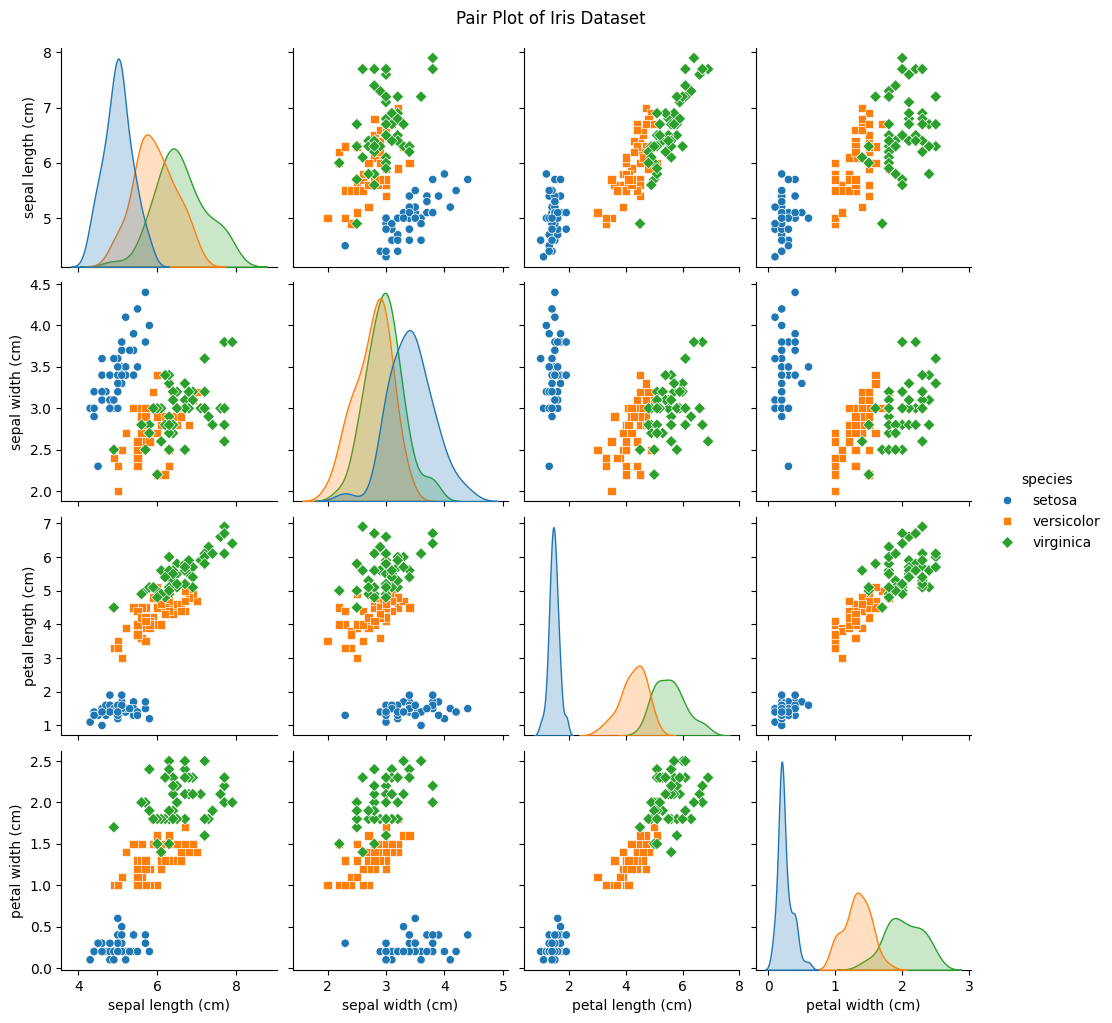

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.pairplot(df, hue="species", markers=["o", "s", "D"])
plt.suptitle("Pair Plot of Iris Dataset", y=1.02)
plt.show()

#***Preparing the data and building the Model***

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
#separating the features and the target
x = df.drop('species', axis=1)
y = df['species']

In [ ]:
#splitting the data into 80% testing and 20% training

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [ ]:
print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (120, 4)
Shape of X_test: (30, 4)
Shape of y_train: (120,)
Shape of y_test: (30,)


#***Training the decision tree model***

In [ ]:
from sklearn.tree import DecisionTreeClassifier

In [ ]:
#Creating an instance of the Decision Tree Classifier
#WE can again use random_state for reproducibility of the model itself
dt_model = DecisionTreeClassifier(random_state=42)

In [ ]:
#train the model on training data
dt_model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

#***Making Predictions***

In [ ]:
y_pred = dt_model.predict(X_test)

In [ ]:
comparison_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
print(comparison_df.head())

         Actual   Predicted
73   versicolor  versicolor
18       setosa      setosa
118   virginica   virginica
78   versicolor  versicolor
76   versicolor  versicolor


#***Evaluating the Model***

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Calculate the accuracy of the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

# For a more detailed look, we can use a classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# A confusion matrix is also a great way to visualize performance
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 1.00

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30


Confusion Matrix:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


#***Visualising the Trained Decision Tree***

# How to Interpret the Tree
Each box in the flowchart is a node.


- The Top Node (Root Node): This is the first question the model asks.
   - petal width (cm) <= 0.8: This is the condition. The model checks if the petal width of a flower is less than or equal to 0.8 cm.
   - gini = 0.667: This is the "Gini impurity," a measure of how mixed the classes are in the node. A Gini of 0 means all samples belong to one class (pure).
   - samples = 120: This tells us that all 120 samples from our training data pass through this node.
   - value = [40, 41, 39]: This shows the distribution of the samples. It means at this node, we have 40 setosa, 41 versicolor, and 39 virginica flowers.
   - class = versicolor: This indicates that the majority class in this node is versicolor.

- Following the Branches:
   - If the condition petal width (cm) <= 0.8 is True, you move down the left branch.
   - If the condition is False, you move down the right branch.

- Leaf Nodes:
   - The nodes at the very bottom of the tree are called leaf nodes. These are the final decisions.
   - For instance, the leftmost leaf node has a Gini of 0.0. This means it's a pure node. All 40 samples that ended up here were correctly classified as setosa. This is our final prediction for any flower that satisfies the preceding conditions.

   
By following the paths from the root to the leaves, you can see the precise set of rules the model has learned to distinguish between the three species of iris flowers.

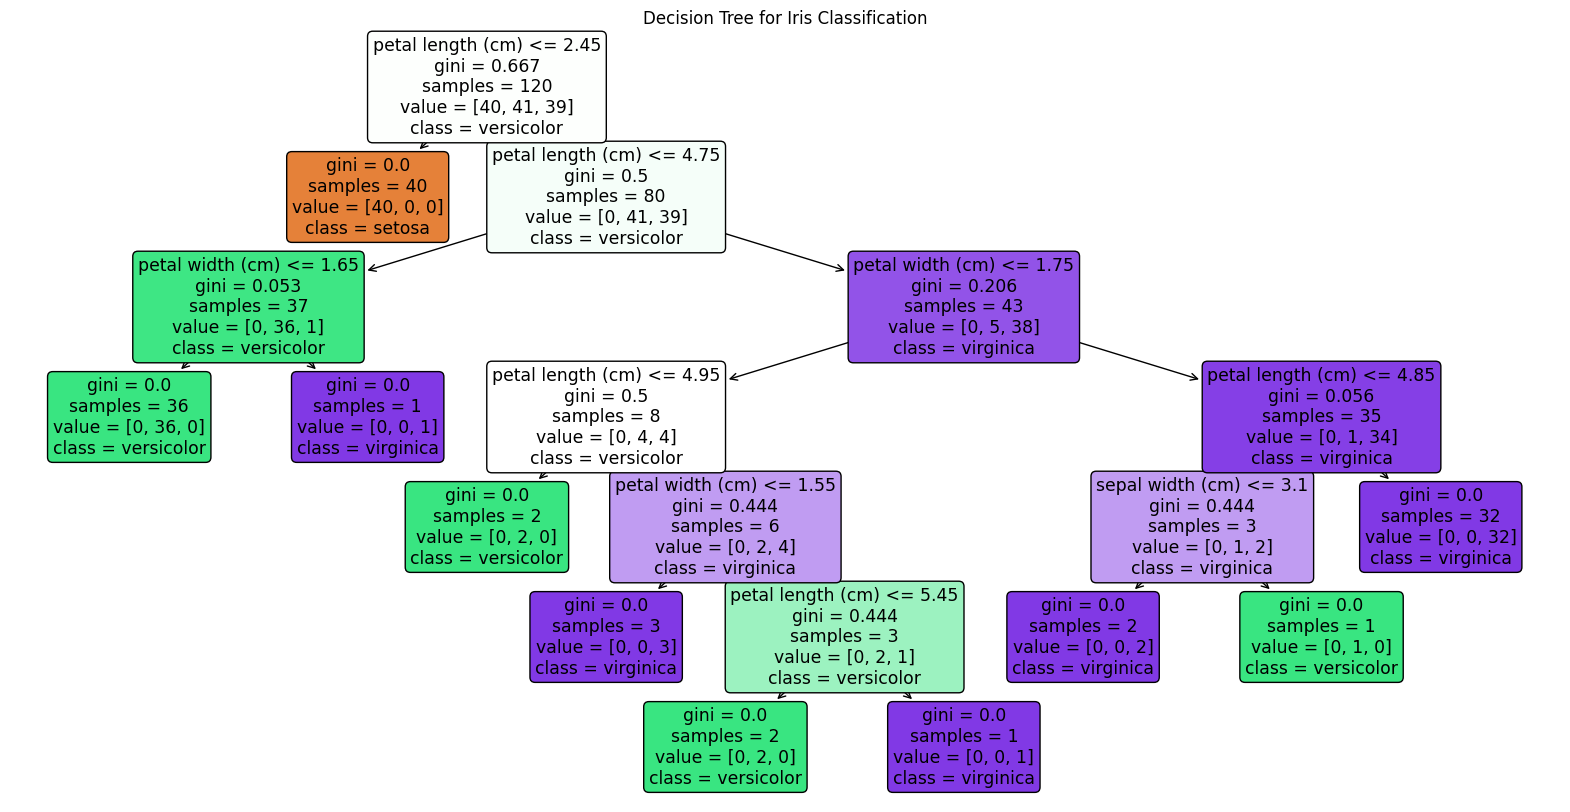

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Set the size of the figure
plt.figure(figsize=(20,10))

# Plot the tree
# feature_names are the names of our columns
# class_names are the names of our target classes
# filled=True colors the nodes to indicate the majority class
plot_tree(dt_model,
          feature_names=iris.feature_names,
          class_names=iris.target_names,
          filled=True,
          rounded=True)

plt.title("Decision Tree for Iris Classification")
plt.show()